# Lab 2. Text, Tokens, and Vocabularies

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wanghemath/Book-MathNLP/blob/main/labs/chapter-02-text-tokens-vocabularies.ipynb)

This lab accompanies Chapter 2 of **Mathematical Natural Language Processing**.

In Chapter 1, we saw the broad NLP pipeline

$$
\text{raw text} \longrightarrow \text{tokens} \longrightarrow \text{vectors} \longrightarrow \text{models}.
$$

This lab studies the first serious representation step in more detail:

$$
\text{raw string} \longrightarrow \text{normalized string} \longrightarrow \text{token sequence} \longrightarrow \text{integer sequence}.
$$

The goal is to make tokenization mathematically explicit and computationally transparent.

## How to use this lab

This notebook is designed for independent study.

1. Read the mathematical explanation before each code block.
2. Run the code cells in order.
3. When you see **Try it yourself**, edit the input text or parameters and rerun the cell.
4. Complete the exercises and mini-project at the end.

No internet access or large NLP library is required.  We use standard Python tools so the representation maps are visible.

## Learning goals

After completing this lab, you should be able to:

- treat text as a string over an alphabet;
- explain normalization as a possibly many-to-one map;
- implement character-level and word-level tokenizers;
- build a finite vocabulary and token-to-integer map;
- encode documents as integer sequences;
- build a document-term matrix from token counts;
- study vocabulary thresholding and unknown tokens;
- compute an empirical token distribution and entropy;
- implement a small educational version of byte-pair encoding;
- compare tokenization strategies for mathematical text.

## 1. Mathematical background: strings, tokens, and vocabularies

Let $A$ be a finite alphabet.  The set of all finite strings over $A$ is

$$
A^* = \{\epsilon\} \cup A \cup A^2 \cup A^3 \cup \cdots,
$$

where $\epsilon$ is the empty string.

A raw text document is an element $x \in A^*$.  A corpus is a finite collection

$$
D = \{x_1,x_2,\ldots,x_n\}.
$$

A tokenizer is a map

$$
\tau: A^* \to V^*,
$$

where $V=\{v_1,\ldots,v_d\}$ is a finite vocabulary.  For a document $x$, the tokenizer returns

$$
\tau(x) = (t_1,t_2,\ldots,t_m), \qquad t_j \in V.
$$

After assigning token IDs, we also have an index map

$$
\iota: V \to \{0,1,\ldots,d-1\}.
$$

The composition $\iota \circ \tau$ converts text into an integer sequence.  This is the form used by many NLP models.

## 2. Setup

We import a few tools:

- `re` for regular expressions;
- `Counter` for token counts;
- `numpy` for numerical arrays;
- `pandas` for tables;
- `matplotlib` for plots.

In [1]:
import re
import math
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
pd.set_option("display.max_colwidth", 120)

## 3. A small corpus with ordinary and mathematical language

We use a small corpus so that every representation can be inspected by hand.  The documents include ordinary words, technical terms, punctuation, and simple mathematical notation.

In [2]:
corpus = [
    "Tokenization maps raw text into tokens.",
    "Language models predict the next token.",
    "A vocabulary defines the coordinates of a text vector.",
    "In probability, P(X > 2) can be estimated from data.",
    "Linear algebra studies vectors, matrices, and maps such as A^T A.",
    "Subword tokens help models handle eigenvectorization and tokenization."
]

for i, doc in enumerate(corpus, start=1):
    print(f"x_{i}: {doc}")

x_1: Tokenization maps raw text into tokens.
x_2: Language models predict the next token.
x_3: A vocabulary defines the coordinates of a text vector.
x_4: In probability, P(X > 2) can be estimated from data.
x_5: Linear algebra studies vectors, matrices, and maps such as A^T A.
x_6: Subword tokens help models handle eigenvectorization and tokenization.


## 4. Normalization as a preprocessing map

A normalizer is a function

$$
N:A^* \to A^*.
$$

Examples include lowercasing, removing punctuation, replacing multiple spaces with one space, or standardizing notation.

Important point: most normalizers are **not injective**.  For example, `Apple` and `apple` both become `apple` after lowercasing.  This may be useful, but it loses information.

In [3]:
def normalize_basic(text):
    """Lowercase, remove punctuation except spaces, and collapse repeated spaces."""
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

examples = [
    "Models, models!",
    "Apple released a model.",
    "apple released a model.",
    "P(X > 2) = 0.13",
    "A^T A is positive semidefinite."
]

for text in examples:
    print(f"Original:   {text}")
    print(f"Normalized: {normalize_basic(text)}")
    print()

Original:   Models, models!
Normalized: models models

Original:   Apple released a model.
Normalized: apple released a model

Original:   apple released a model.
Normalized: apple released a model

Original:   P(X > 2) = 0.13
Normalized: p x 2 0 13

Original:   A^T A is positive semidefinite.
Normalized: a t a is positive semidefinite



### Try it yourself

Change the examples above.  Include one sentence with capitalization, one with punctuation, and one with mathematical symbols.  Ask: what information did the normalizer discard?

## 5. Character-level tokenization

A character tokenizer uses individual characters as tokens:

$$
\tau_{\text{char}}(x) = (c_1,c_2,\ldots,c_m).
$$

Character tokenization usually has a small vocabulary and no unknown word problem.  Its weakness is that sequences become long and semantic units are hard to identify.

In [4]:
def char_tokenize(text, keep_spaces=False):
    """Character tokenizer. Optionally keep spaces as tokens."""
    text = text.lower()
    if not keep_spaces:
        text = text.replace(" ", "")
    return list(text)

sample = "Tokenization!"
print("Text:", sample)
print("Character tokens:", char_tokenize(sample))
print("Number of character tokens:", len(char_tokenize(sample)))

Text: Tokenization!
Character tokens: ['t', 'o', 'k', 'e', 'n', 'i', 'z', 'a', 't', 'i', 'o', 'n', '!']
Number of character tokens: 13


## 6. Word-level tokenization

A word tokenizer splits text into word-like units.  Here we implement a transparent tokenizer that keeps alphabetic words and numbers:

$$
\tau_{\text{word}}(x)=(w_1,w_2,\ldots,w_m).
$$

This is interpretable, but it may lose punctuation and mathematical structure.

In [5]:
def word_tokenize(text):
    """Simple word tokenizer: lowercase and extract words/numbers."""
    return re.findall(r"[a-zA-Z]+|[0-9]+", text.lower())

tokenized_corpus = [word_tokenize(doc) for doc in corpus]

for i, tokens in enumerate(tokenized_corpus, start=1):
    print(f"tokens(x_{i}) = {tokens}")

tokens(x_1) = ['tokenization', 'maps', 'raw', 'text', 'into', 'tokens']
tokens(x_2) = ['language', 'models', 'predict', 'the', 'next', 'token']
tokens(x_3) = ['a', 'vocabulary', 'defines', 'the', 'coordinates', 'of', 'a', 'text', 'vector']
tokens(x_4) = ['in', 'probability', 'p', 'x', '2', 'can', 'be', 'estimated', 'from', 'data']
tokens(x_5) = ['linear', 'algebra', 'studies', 'vectors', 'matrices', 'and', 'maps', 'such', 'as', 'a', 't', 'a']
tokens(x_6) = ['subword', 'tokens', 'help', 'models', 'handle', 'eigenvectorization', 'and', 'tokenization']


### Compare character and word lengths

The same document can have very different sequence lengths under different tokenizers.  This matters because many NLP algorithms scale with sequence length.

In [6]:
length_rows = []
for i, doc in enumerate(corpus, start=1):
    length_rows.append({
        "document": f"x_{i}",
        "characters_no_spaces": len(char_tokenize(doc, keep_spaces=False)),
        "word_tokens": len(word_tokenize(doc))
    })

length_table = pd.DataFrame(length_rows)
length_table

,document,characters_no_spaces,word_tokens
0,x_1,34,6
1,x_2,34,6
2,x_3,46,9
3,x_4,43,10
4,x_5,55,12
5,x_6,63,8


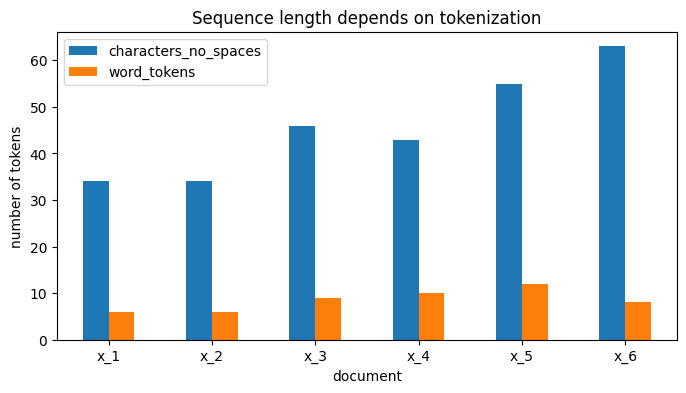

In [7]:
ax = length_table.set_index("document")[ ["characters_no_spaces", "word_tokens"] ].plot(kind="bar", figsize=(8, 4))
ax.set_title("Sequence length depends on tokenization")
ax.set_ylabel("number of tokens")
ax.set_xlabel("document")
plt.xticks(rotation=0)
plt.show()

## 7. Vocabulary construction

Given tokenized documents, the vocabulary is the set of distinct tokens:

$$
V = \{v_1,v_2,\ldots,v_d\}.
$$

A vocabulary is not only a list.  It determines the dimension $d$ of one-hot vectors and count vectors.

In [8]:
all_tokens = [token for doc in tokenized_corpus for token in doc]
counts = Counter(all_tokens)

vocab = sorted(counts)
token_to_id = {token: j for j, token in enumerate(vocab)}
id_to_token = {j: token for token, j in token_to_id.items()}

print("Number of total token occurrences:", len(all_tokens))
print("Vocabulary size:", len(vocab))
print("First 20 vocabulary items:")
print(vocab[:20])

Number of total token occurrences: 51
Vocabulary size: 41
First 20 vocabulary items:
['2', 'a', 'algebra', 'and', 'as', 'be', 'can', 'coordinates', 'data', 'defines', 'eigenvectorization', 'estimated', 'from', 'handle', 'help', 'in', 'into', 'language', 'linear', 'maps']


In [9]:
freq_table = pd.DataFrame(
    sorted(counts.items(), key=lambda item: (-item[1], item[0])),
    columns=["token", "frequency"]
)
freq_table.head(20)

,token,frequency
0,a,4
1,and,2
2,maps,2
3,models,2
4,text,2
5,the,2
6,tokenization,2
7,tokens,2
8,2,1
9,algebra,1


## 8. Integer encoding

The index map

$$
\iota:V\to\{0,1,\ldots,d-1\}
$$

assigns each token an integer.  A token sequence then becomes an integer sequence:

$$
(t_1,t_2,\ldots,t_m) \mapsto (\iota(t_1),\iota(t_2),\ldots,\iota(t_m)).
$$

This is the representation that can be passed into embedding layers and many neural models.

In [10]:
integer_sequences = [[token_to_id[token] for token in doc] for doc in tokenized_corpus]

for i, ids in enumerate(integer_sequences, start=1):
    print(f"ids(x_{i}) = {ids}")

ids(x_1) = [35, 19, 27, 32, 16, 36]
ids(x_2) = [17, 21, 25, 33, 22, 34]
ids(x_3) = [1, 39, 9, 33, 7, 23, 1, 32, 37]
ids(x_4) = [15, 26, 24, 40, 0, 6, 5, 11, 12, 8]
ids(x_5) = [18, 2, 28, 38, 20, 3, 19, 30, 4, 1, 31, 1]
ids(x_6) = [29, 36, 14, 21, 13, 10, 3, 35]


In [11]:
# Decode one integer sequence back to tokens.
example_id_sequence = integer_sequences[1]
decoded = [id_to_token[j] for j in example_id_sequence]

print("Integer sequence:", example_id_sequence)
print("Decoded tokens:   ", decoded)

Integer sequence: [17, 21, 25, 33, 22, 34]
Decoded tokens:    ['language', 'models', 'predict', 'the', 'next', 'token']


## 9. One-hot vectors

If the vocabulary has size $d$, each token $v_j$ can be represented by the $j$th standard basis vector:

$$
\phi(v_j)=e_j \in R^d.
$$

One-hot vectors encode token identity, not semantic similarity.  Distinct tokens are orthogonal.

In [12]:
def one_hot(token, token_to_id):
    d = len(token_to_id)
    vector = np.zeros(d, dtype=int)
    vector[token_to_id[token]] = 1
    return vector

for token in ["tokenization", "models", "data"]:
    if token in token_to_id:
        vec = one_hot(token, token_to_id)
        print(f"token = {token!r}")
        print("id =", token_to_id[token])
        print("nonzero coordinates:", np.nonzero(vec)[0].tolist())
        print()

token = 'tokenization'
id = 35
nonzero coordinates: [35]

token = 'models'
id = 21
nonzero coordinates: [21]

token = 'data'
id = 8
nonzero coordinates: [8]



## 10. Bag-of-words count vectors

The count vector of a document is

$$
c(x)=(c_1(x),\ldots,c_d(x)) \in N^d,
$$

where

$$
c_j(x)=\#\{k:t_k=v_j\}.
$$

This representation keeps token counts but discards word order.

In [13]:
def count_vector(tokens, vocab):
    doc_counts = Counter(tokens)
    return np.array([doc_counts[token] for token in vocab], dtype=int)

count_vectors = np.vstack([count_vector(tokens, vocab) for tokens in tokenized_corpus])

print("Shape of count-vector matrix:", count_vectors.shape)
print("First document count vector:")
print(count_vectors[0])

Shape of count-vector matrix: (6, 41)
First document count vector:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 1
 0 0 0 0]


## 11. Document-term matrix

For a corpus $D=\{x_1,\ldots,x_n\}$ and vocabulary $V=\{v_1,\ldots,v_d\}$, the document-term matrix is

$$
X\in R^{n\times d}, \qquad X_{ij}=c_j(x_i).
$$

Rows are documents.  Columns are tokens.

In [14]:
X = pd.DataFrame(count_vectors, index=[f"x_{i}" for i in range(1, len(corpus)+1)], columns=vocab)
X

,2,a,algebra,and,as,be,can,coordinates,data,defines,eigenvectorization,estimated,from,handle,help,in,into,language,linear,maps,matrices,models,next,of,p,predict,probability,raw,studies,subword,such,t,text,the,token,tokenization,tokens,vector,vectors,vocabulary,x
x_1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0
x_2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0
x_3,0,2,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,1,0
x_4,1,0,0,0,0,1,1,0,1,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
x_5,0,2,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,0
x_6,0,0,0,1,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0


In [15]:
row_sums = X.sum(axis=1)
column_sums = X.sum(axis=0).sort_values(ascending=False)

print("Document lengths from row sums:")
print(row_sums)
print()
print("Most frequent tokens from column sums:")
print(column_sums.head(10))

Document lengths from row sums:
x_1     6
x_2     6
x_3     9
x_4    10
x_5    12
x_6     8
dtype: int64

Most frequent tokens from column sums:
a               4
and             2
tokens          2
tokenization    2
the             2
text            2
models          2
maps            2
2               1
data            1
dtype: int64


### Order loss in bag-of-words

Two different sentences may have the same count vector.  Therefore the bag-of-words map is not injective.

In [16]:
s1 = "models use data"
s2 = "data use models"

t1 = word_tokenize(s1)
t2 = word_tokenize(s2)
small_vocab = sorted(set(t1 + t2))

v1 = count_vector(t1, small_vocab)
v2 = count_vector(t2, small_vocab)

print("Vocabulary:", small_vocab)
print("Sentence 1 tokens:", t1)
print("Sentence 2 tokens:", t2)
print("Count vector 1:", v1)
print("Count vector 2:", v2)
print("Same count vector?", np.array_equal(v1, v2))

Vocabulary: ['data', 'models', 'use']
Sentence 1 tokens: ['models', 'use', 'data']
Sentence 2 tokens: ['data', 'use', 'models']
Count vector 1: [1 1 1]
Count vector 2: [1 1 1]
Same count vector? True


## 12. Vocabulary thresholding

In larger corpora, many tokens occur only once.  A common vocabulary selection rule is

$$
V_r = \{v : f(v) \ge r\},
$$

where $f(v)$ is the corpus frequency of token $v$.

Larger $r$ gives a smaller vocabulary.  This can reduce noise and sparsity, but it can also remove important rare words.

In [17]:
threshold_rows = []
max_freq = max(counts.values())
for r in range(1, max_freq + 1):
    kept = [token for token, freq in counts.items() if freq >= r]
    removed = [token for token, freq in counts.items() if freq < r]
    threshold_rows.append({
        "threshold_r": r,
        "vocabulary_size": len(kept),
        "removed_tokens": len(removed)
    })

threshold_table = pd.DataFrame(threshold_rows)
threshold_table

,threshold_r,vocabulary_size,removed_tokens
0,1,41,0
1,2,8,33
2,3,1,40
3,4,1,40


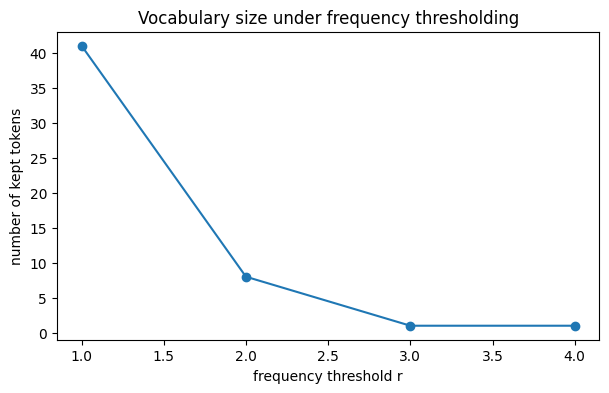

In [18]:
ax = threshold_table.plot(x="threshold_r", y="vocabulary_size", marker="o", figsize=(7, 4), legend=False)
ax.set_title("Vocabulary size under frequency thresholding")
ax.set_xlabel("frequency threshold r")
ax.set_ylabel("number of kept tokens")
plt.show()

### Inspect the tokens kept at a threshold

The next cell builds a new vocabulary using a threshold.  Try changing `r`.

In [19]:
r = 2
threshold_vocab = sorted([token for token, freq in counts.items() if freq >= r])
removed_tokens = sorted([token for token, freq in counts.items() if freq < r])

print("Threshold r =", r)
print("Kept vocabulary:", threshold_vocab)
print("Removed tokens:", removed_tokens)

Threshold r = 2
Kept vocabulary: ['a', 'and', 'maps', 'models', 'text', 'the', 'tokenization', 'tokens']
Removed tokens: ['2', 'algebra', 'as', 'be', 'can', 'coordinates', 'data', 'defines', 'eigenvectorization', 'estimated', 'from', 'handle', 'help', 'in', 'into', 'language', 'linear', 'matrices', 'next', 'of', 'p', 'predict', 'probability', 'raw', 'studies', 'subword', 'such', 't', 'token', 'vector', 'vectors', 'vocabulary', 'x']


## 13. Unknown tokens

If a new document contains a token outside the vocabulary, a simple solution is to replace it by `[UNK]`.

Mathematically, this is a projection-like map

$$
\pi(v)=
\begin{cases}
v, & v\in V,\\
\text{[UNK]}, & v\notin V.
\end{cases}
$$

This solves the finite-vocabulary problem, but it collapses many different unseen tokens into one symbol.

In [20]:
base_vocab = threshold_vocab.copy()
special_tokens = ["[PAD]", "[UNK]"]
vocab_with_special = special_tokens + base_vocab
special_token_to_id = {token: j for j, token in enumerate(vocab_with_special)}

def encode_with_unknown(text, token_to_id):
    tokens = word_tokenize(text)
    unk_id = token_to_id["[UNK]"]
    ids = [token_to_id.get(token, unk_id) for token in tokens]
    mapped_tokens = [token if token in token_to_id else "[UNK]" for token in tokens]
    return tokens, mapped_tokens, ids

new_text = "Noetherian eigenvectorization uses matrices and graph tokenizers."
original_tokens, mapped_tokens, ids = encode_with_unknown(new_text, special_token_to_id)

print("New text:", new_text)
print("Original tokens:", original_tokens)
print("Mapped tokens:  ", mapped_tokens)
print("Integer IDs:    ", ids)

New text: Noetherian eigenvectorization uses matrices and graph tokenizers.
Original tokens: ['noetherian', 'eigenvectorization', 'uses', 'matrices', 'and', 'graph', 'tokenizers']
Mapped tokens:   ['[UNK]', '[UNK]', '[UNK]', '[UNK]', 'and', '[UNK]', '[UNK]']
Integer IDs:     [1, 1, 1, 1, 3, 1, 1]


### Try it yourself

Change `new_text` to a sentence from mathematics, statistics, or computer science.  Which words become `[UNK]`?  Are they important words?

## 14. Padding and truncation

Neural network batches often require equal-length sequences.  We choose a maximum length $L$.

- If a sequence is shorter than $L$, append `[PAD]` IDs.
- If a sequence is longer than $L$, cut it to length $L$.

We also create a mask indicating which positions are real tokens and which positions are padding.

In [21]:
def pad_or_truncate(ids, max_length, pad_id=0):
    ids = list(ids)
    if len(ids) >= max_length:
        trimmed = ids[:max_length]
        mask = [1] * max_length
    else:
        trimmed = ids + [pad_id] * (max_length - len(ids))
        mask = [1] * len(ids) + [0] * (max_length - len(ids))
    return trimmed, mask

max_length = 8
encoded_rows = []
for doc in corpus:
    _, _, ids = encode_with_unknown(doc, special_token_to_id)
    padded, mask = pad_or_truncate(ids, max_length=max_length, pad_id=special_token_to_id["[PAD]"])
    encoded_rows.append({
        "text": doc,
        "ids_padded_or_truncated": padded,
        "mask": mask
    })

pd.DataFrame(encoded_rows)

,text,ids_padded_or_truncated,mask
0,Tokenization maps raw text into tokens.,"[8, 4, 1, 6, 1, 9, 0, 0]","[1, 1, 1, 1, 1, 1, 0, 0]"
1,Language models predict the next token.,"[1, 5, 1, 7, 1, 1, 0, 0]","[1, 1, 1, 1, 1, 1, 0, 0]"
2,A vocabulary defines the coordinates of a text vector.,"[2, 1, 1, 7, 1, 1, 2, 6]","[1, 1, 1, 1, 1, 1, 1, 1]"
3,"In probability, P(X > 2) can be estimated from data.","[1, 1, 1, 1, 1, 1, 1, 1]","[1, 1, 1, 1, 1, 1, 1, 1]"
4,"Linear algebra studies vectors, matrices, and maps such as A^T A.","[1, 1, 1, 1, 1, 3, 4, 1]","[1, 1, 1, 1, 1, 1, 1, 1]"
5,Subword tokens help models handle eigenvectorization and tokenization.,"[1, 9, 1, 5, 1, 1, 3, 8]","[1, 1, 1, 1, 1, 1, 1, 1]"


## 15. Empirical token distribution and entropy

Given token frequencies $f_j$ and total token count $M$, define

$$
\hat p_j=\frac{f_j}{M}.
$$

The vector $\hat p$ is an empirical probability distribution over the vocabulary.  Its entropy is

$$
\widehat H = -\sum_j \hat p_j \log \hat p_j.
$$

A distribution spread across many tokens has larger entropy than one dominated by a few repeated tokens.

In [22]:
M = sum(counts.values())
empirical_distribution = {token: freq / M for token, freq in counts.items()}
entropy = -sum(p * math.log(p) for p in empirical_distribution.values())

entropy_table = pd.DataFrame(
    sorted(empirical_distribution.items(), key=lambda item: (-item[1], item[0])),
    columns=["token", "empirical_probability"]
)

print("Total token count M:", M)
print("Vocabulary size d:", len(vocab))
print("Empirical entropy:", round(entropy, 4))
entropy_table.head(12)

Total token count M: 51
Vocabulary size d: 41
Empirical entropy: 3.6328


,token,empirical_probability
0,a,0.078431
1,and,0.039216
2,maps,0.039216
3,models,0.039216
4,text,0.039216
5,the,0.039216
6,tokenization,0.039216
7,tokens,0.039216
8,2,0.019608
9,algebra,0.019608


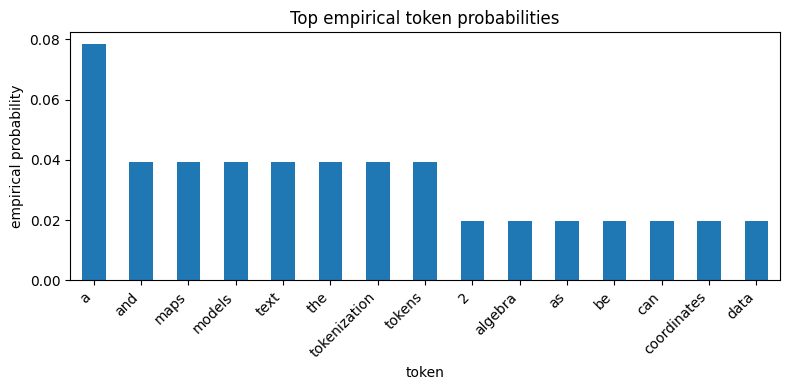

In [23]:
top = entropy_table.head(15)
ax = top.plot(x="token", y="empirical_probability", kind="bar", figsize=(8, 4), legend=False)
ax.set_title("Top empirical token probabilities")
ax.set_xlabel("token")
ax.set_ylabel("empirical probability")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 16. Rank-frequency and vocabulary growth

Natural language often has many rare tokens.  Two useful empirical summaries are:

1. **Rank-frequency behavior:** sort tokens by frequency and plot frequency versus rank.
2. **Vocabulary growth:** scan through a corpus and count how many distinct tokens have been observed so far.

The small corpus here is too small for serious statistical conclusions, but the code shows the method.

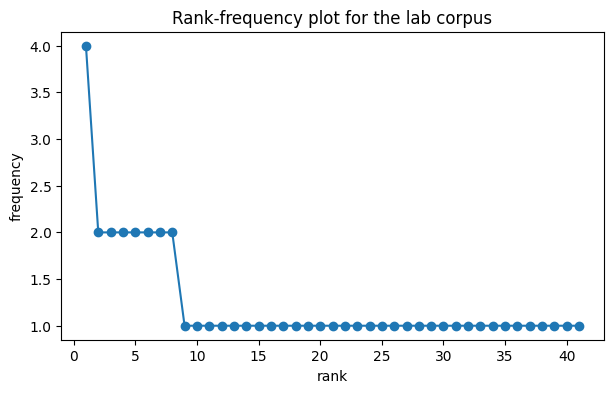

In [24]:
ranked_frequencies = np.array(sorted(counts.values(), reverse=True))
ranks = np.arange(1, len(ranked_frequencies) + 1)

plt.figure(figsize=(7, 4))
plt.plot(ranks, ranked_frequencies, marker="o")
plt.title("Rank-frequency plot for the lab corpus")
plt.xlabel("rank")
plt.ylabel("frequency")
plt.show()

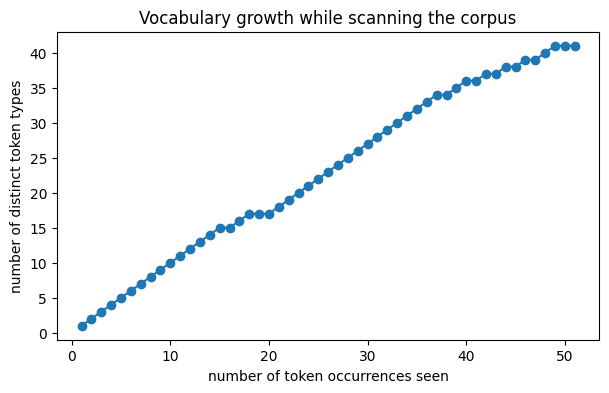

In [25]:
seen = set()
growth = []
for m, token in enumerate(all_tokens, start=1):
    seen.add(token)
    growth.append({"tokens_seen": m, "vocabulary_size": len(seen)})

growth_df = pd.DataFrame(growth)

plt.figure(figsize=(7, 4))
plt.plot(growth_df["tokens_seen"], growth_df["vocabulary_size"], marker="o")
plt.title("Vocabulary growth while scanning the corpus")
plt.xlabel("number of token occurrences seen")
plt.ylabel("number of distinct token types")
plt.show()

## 17. A tiny educational BPE implementation

Subword tokenization tries to balance the strengths of character and word tokenization.

A simple byte-pair encoding style procedure starts with characters and repeatedly merges frequent adjacent pairs.  At each step:

1. count adjacent token pairs;
2. find a most frequent pair;
3. merge that pair into a new token;
4. repeat.

This is a greedy compression-like algorithm.  The implementation below is intentionally small and educational.

In [26]:
def word_as_chars(word):
    """Represent a word as characters plus an end-of-word marker."""
    return tuple(list(word) + ["</w>"])

def pair_counts(sequences):
    counts = Counter()
    for seq in sequences:
        for a, b in zip(seq[:-1], seq[1:]):
            counts[(a, b)] += 1
    return counts

def merge_pair(sequence, pair):
    a, b = pair
    merged = []
    i = 0
    while i < len(sequence):
        if i < len(sequence) - 1 and sequence[i] == a and sequence[i + 1] == b:
            merged.append(a + b)
            i += 2
        else:
            merged.append(sequence[i])
            i += 1
    return tuple(merged)

def bpe_step(sequences):
    counts = pair_counts(sequences)
    best_pair, best_count = counts.most_common(1)[0]
    new_sequences = [merge_pair(seq, best_pair) for seq in sequences]
    return best_pair, best_count, new_sequences

words = ["low", "lower", "lowest", "new", "newer", "newest", "low", "lower", "low"]
sequences = [word_as_chars(w) for w in words]

print("Initial character sequences:")
for seq in sequences[:5]:
    print(seq)

Initial character sequences:
('l', 'o', 'w', '</w>')
('l', 'o', 'w', 'e', 'r', '</w>')
('l', 'o', 'w', 'e', 's', 't', '</w>')
('n', 'e', 'w', '</w>')
('n', 'e', 'w', 'e', 'r', '</w>')


In [27]:
sequences = [word_as_chars(w) for w in words]
merge_history = []

for step in range(8):
    best_pair, best_count, sequences = bpe_step(sequences)
    merge_history.append({
        "step": step + 1,
        "merged_pair": best_pair,
        "frequency": best_count,
        "example_after_merge": sequences[0]
    })

pd.DataFrame(merge_history)

,step,merged_pair,frequency,example_after_merge
0,1,"(l, o)",6,"(lo, w, </w>)"
1,2,"(lo, w)",6,"(low, </w>)"
2,3,"(low, </w>)",3,"(low</w>,)"
3,4,"(low, e)",3,"(low</w>,)"
4,5,"(r, </w>)",3,"(low</w>,)"
5,6,"(n, e)",3,"(low</w>,)"
6,7,"(ne, w)",3,"(low</w>,)"
7,8,"(lowe, r</w>)",2,"(low</w>,)"


In [28]:
print("Final learned-looking segmentations:")
for word, seq in zip(words[:6], sequences[:6]):
    print(f"{word:8s} -> {seq}")

Final learned-looking segmentations:
low      -> ('low</w>',)
lower    -> ('lower</w>',)
lowest   -> ('lowe', 's', 't', '</w>')
new      -> ('new', '</w>')
newer    -> ('new', 'e', 'r</w>')
newest   -> ('new', 'e', 's', 't', '</w>')


### What this tiny BPE example teaches

This educational BPE example shows three important facts:

- subword units are learned from data;
- frequent local patterns become larger tokens;
- the same word can be segmented differently if the training corpus changes.

Production tokenizers include many additional details, but the mathematical idea of a data-dependent vocabulary remains central.

## 18. A math-aware tokenizer

A simple word tokenizer can badly damage mathematical notation.  For example,

```text
P(X > 2) = 0.13
```

might become `p`, `x`, `2`, `0`, `13`, which loses the structure of the expression.

For mathematical NLP, we often want to keep symbolic pieces such as `A^T`, `x_i`, `nabla`, numbers, and comparison operators.

The tokenizer below is not perfect.  It is a readable first attempt.

In [29]:
def math_aware_tokenize(text):
    """A simple tokenizer that tries to preserve some mathematical tokens.

    It keeps:
    - words such as tokenization and matrix;
    - identifiers with optional subscripts or superscripts such as x_i and A^T;
    - decimal numbers;
    - comparison and arithmetic symbols;
    - parentheses.
    """
    pattern = r"""
        [A-Za-z]+(?:[_^][A-Za-z0-9]+)?   # word or symbol with one sub/superscript
        | \d+\.\d+                       # decimal number
        | \d+                             # integer
        | >=|<=|!=|==                     # two-character comparison operators
        | [=<>+\-*/^()]                   # single-character math symbols
    """
    return re.findall(pattern, text, flags=re.VERBOSE)

math_examples = [
    "P(X > 2) = 0.13",
    "A^T A is positive semidefinite",
    "The gradient nabla_f points in a steep direction",
    "x_i depends on x_{i-1} in a sequence model"
]

for text in math_examples:
    print("Text:", text)
    print("word_tokenize:", word_tokenize(text))
    print("math_aware:   ", math_aware_tokenize(text))
    print()

Text: P(X > 2) = 0.13
word_tokenize: ['p', 'x', '2', '0', '13']
math_aware:    ['P', '(', 'X', '>', '2', ')', '=', '0.13']

Text: A^T A is positive semidefinite
word_tokenize: ['a', 't', 'a', 'is', 'positive', 'semidefinite']
math_aware:    ['A^T', 'A', 'is', 'positive', 'semidefinite']

Text: The gradient nabla_f points in a steep direction
word_tokenize: ['the', 'gradient', 'nabla', 'f', 'points', 'in', 'a', 'steep', 'direction']
math_aware:    ['The', 'gradient', 'nabla_f', 'points', 'in', 'a', 'steep', 'direction']

Text: x_i depends on x_{i-1} in a sequence model
word_tokenize: ['x', 'i', 'depends', 'on', 'x', 'i', '1', 'in', 'a', 'sequence', 'model']
math_aware:    ['x_i', 'depends', 'on', 'x', 'i', '-', '1', 'in', 'a', 'sequence', 'model']



### Try it yourself

Improve the tokenizer above so it handles one of the following better:

- `x_{i-1}` as one token;
- `A^T A` as two matrix-related tokens;
- LaTeX-like commands such as `\nabla`, `\alpha`, or `\sum`;
- probabilities such as `P(X > 2)`.

Tokenizer design is a modeling decision.  There is no single correct answer for all tasks.

## 19. Comparing tokenization strategies

Let us compare character, word, and math-aware tokenization on the same paragraph.  We report:

- sequence length;
- vocabulary size;
- sample tokens.

In [30]:
paragraph = """
For a matrix A, the expression A^T A is symmetric and positive semidefinite.
In a language model, tokenization determines the sample space for next-token prediction.
""".strip()

strategies = {
    "character_no_spaces": lambda s: char_tokenize(s, keep_spaces=False),
    "word": word_tokenize,
    "math_aware": math_aware_tokenize
}

comparison_rows = []
for name, tokenizer in strategies.items():
    tokens = tokenizer(paragraph)
    comparison_rows.append({
        "strategy": name,
        "sequence_length": len(tokens),
        "vocabulary_size": len(set(tokens)),
        "first_20_tokens": tokens[:20]
    })

pd.DataFrame(comparison_rows)

,strategy,sequence_length,vocabulary_size,first_20_tokens
0,character_no_spaces,142,27,"[f, o, r, a, m, a, t, r, i, x, a, ,, t, h, e, e, x, p, r, e]"
1,word,27,21,"[for, a, matrix, a, the, expression, a, t, a, is, symmetric, and, positive, semidefinite, in, a, language, model, to..."
2,math_aware,27,24,"[For, a, matrix, A, the, expression, A^T, A, is, symmetric, and, positive, semidefinite, In, a, language, model, tok..."


## 20. AI-assisted tokenizer audit

Use an AI assistant as a checker, not as a replacement for your own reasoning.

A useful prompt is:

> Tokenize the sentence below in three ways: character-level, word-level, and a plausible subword-level segmentation.  Then explain what information is preserved and what information is lost by each representation.  Sentence: `Mathematical tokenization changes the sample space.`

After receiving an answer, check whether the assistant clearly identifies:

- the domain and codomain of the tokenizer;
- which information is lost;
- whether the vocabulary is finite;
- how unknown words would be handled;
- whether mathematical notation requires special treatment.

Do not paste private student data or confidential documents into public AI tools.

## 21. Exercises

Complete the following in your own notebook or in the cells below.

1. Let $A=\{a,b\}$.  List all strings in $A^*$ of length at most $3$.  How many are there?
2. Tokenize the sentence `Data, data, models!` using `normalize_basic` and `word_tokenize`.  What changes?
3. Let $V=\{\text{data},\text{model},\text{token}\}$.  Write the count vector for `data data model token` using this vocabulary order.
4. Construct the document-term matrix for:
   - `data models data`
   - `language models language`
   - `data language token`
5. Give two different sentences with the same bag-of-words vector.
6. In a vocabulary of size $50,000$, what is the dimension of a one-hot vector?  How many nonzero coordinates does it have?
7. Explain why replacing unseen words by `[UNK]` is many-to-one.
8. Change the threshold `r` in Section 12.  Which important tokens disappear first?
9. Modify `math_aware_tokenize` to better preserve one mathematical expression.
10. Run the BPE example on a new list of words from a mathematical topic, such as `linear`, `linearity`, `nonlinear`, and `bilinear`.

### Exercise workspace

Use this section for your own code.

In [31]:
# Exercise workspace
# Write your own code here.

## 22. Mini-project: tokenizer design for mathematical documents

Choose a short paragraph from a mathematical textbook, lecture note, or a synthetic example that you write yourself.

Compare three tokenization strategies:

1. character-level tokenization;
2. word-level tokenization;
3. a manually designed math-aware tokenization.

For each strategy, report:

- number of tokens;
- vocabulary size;
- examples of ambiguous tokens;
- information preserved;
- information lost;
- whether the representation is suitable for search, classification, or language modeling.

A strong mini-project answer should explain not only what the tokenizer outputs, but also what mathematical object the output lives in.

## 23. Summary

In this lab, we studied tokenization as a mathematical representation map.

Main objects:

| Object | Mathematical form | Python object |
|---|---|---|
| raw text | $x \in A^*$ | string |
| normalized text | $N(x)$ | string |
| token sequence | $\tau(x)\in V^*$ | list of strings |
| integer sequence | $(\iota\circ\tau)(x)$ | list of integers |
| vocabulary | $V=\{v_1,\ldots,v_d\}$ | list or dictionary |
| count vector | $c(x)\in N^d$ | NumPy array |
| document-term matrix | $X\in R^{n\times d}$ | pandas DataFrame |
| empirical distribution | $\hat p\in \Delta^{d-1}$ | dictionary or array |

Key message: tokenization is not merely cleaning.  It defines the finite sample space, the coordinates of vectors, and the statistical problem solved by later NLP models.